<a href="https://colab.research.google.com/github/Parthpatil294/ML_6D_1BM23CS227/blob/main/LAB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LOGISTIC REGRESSION - BINARY CLASSIFICATION**

# Task
Build a logistic regression model to predict employee retention using the dataset "/content/HR_comma_sep.csv". Perform exploratory data analysis to visualize how salary and department affect retention, preprocess the data by encoding categorical variables, split the data into training and testing sets, and evaluate the model's accuracy.

## Load Dataset

### Subtask:
Load the HR dataset from a CSV file into a pandas DataFrame and inspect its contents.


**Reasoning**:
Load the HR dataset using pandas and inspect the initial rows to verify successful loading.



In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/HR_comma_sep.csv')

# Display the first few rows
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Initial Data Exploration

### Subtask:
Perform initial data exploration to understand the dataset's structure, identify missing values, and review descriptive statistics.


**Reasoning**:
I will perform initial data exploration by checking the dataframe information, calculating descriptive statistics, and identifying any missing values as requested in the subtask instructions.



In [2]:
# 1. Check data types and non-null counts
print("--- Dataframe Info ---")
df.info()

# 2. View summary statistics for numerical columns
print("\n--- Descriptive Statistics ---")
print(df.describe())

# 3. Check for missing values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB

--- Descriptive Statistics ---
       satisfaction_level  last_evaluation  number_project  \
count        14999.000000     14999.000000    14999.000000   
mean             0.612834 

## Analyze Salary Impact on Retention

### Subtask:
Visualize the impact of employee salaries on retention by creating a bar chart.


**Reasoning**:
I will import the necessary visualization libraries and create a bar chart using a pandas crosstab to visualize the relationship between salary levels and employee retention.



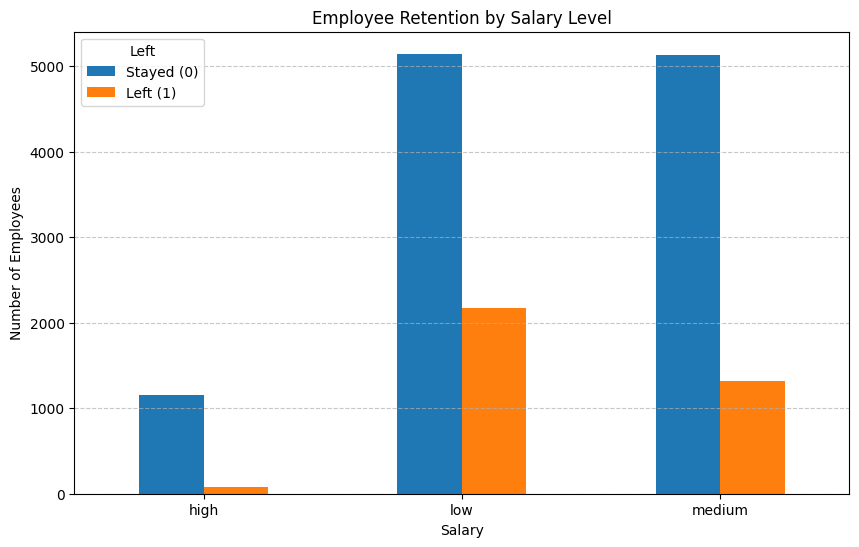

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a crosstab between salary and the target variable 'left'
salary_retention_crosstab = pd.crosstab(df['salary'], df['left'])

# Plot the bar chart
salary_retention_crosstab.plot(kind='bar', figsize=(10, 6))

# Adding labels and title
plt.title('Employee Retention by Salary Level')
plt.xlabel('Salary')
plt.ylabel('Number of Employees')
plt.legend(title='Left', labels=['Stayed (0)', 'Left (1)'])
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

## Analyze Department Impact on Retention

### Subtask:
Visualize the correlation between different departments and employee retention using a bar chart.


**Reasoning**:
I will create a crosstab between 'Department' and 'left' and then plot a bar chart to visualize how employee retention varies across different departments as specified in the instructions.



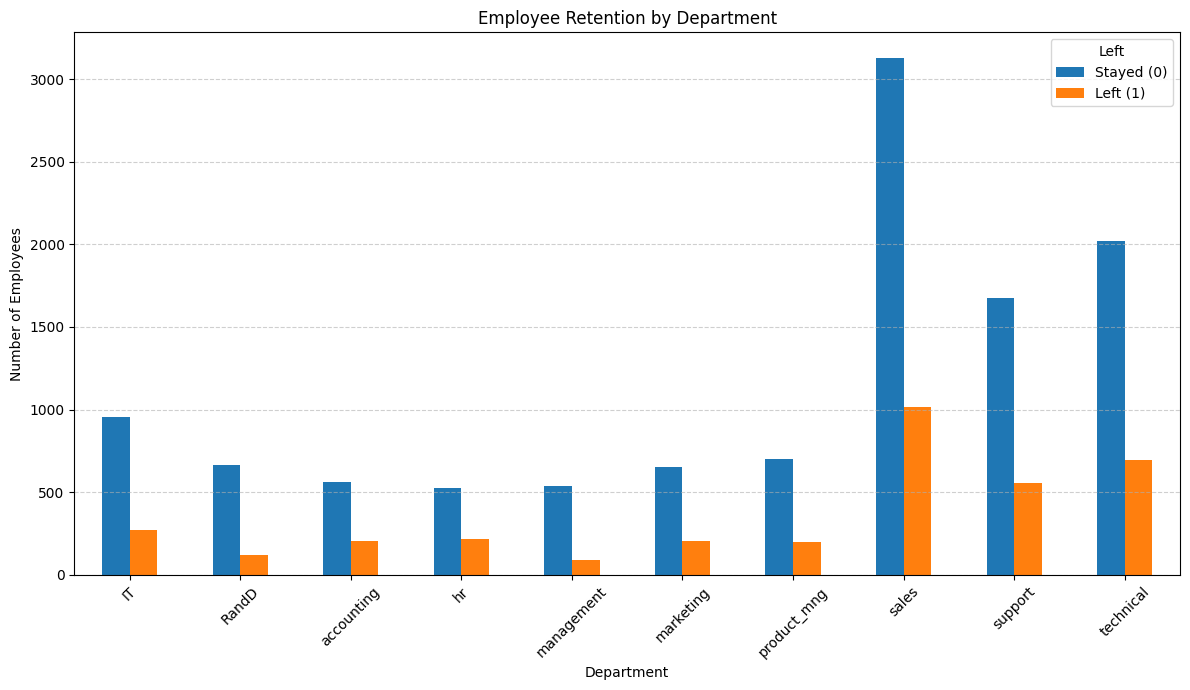

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a cross-tabulation between 'Department' and 'left'
dept_retention_crosstab = pd.crosstab(df['Department'], df['left'])

# 2-3. Generate a grouped bar chart with a legible figure size
dept_retention_crosstab.plot(kind='bar', figsize=(12, 7))

# 4-5. Add title, labels, and legend
plt.title('Employee Retention by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.legend(title='Left', labels=['Stayed (0)', 'Left (1)'])
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 6. Display the plot
plt.tight_layout()
plt.show()

## Prepare Data for Modeling

### Subtask:
Preprocess the dataset by encoding categorical variables and defining features and target for the logistic regression model.


**Reasoning**:
I will perform one-hot encoding on 'salary' and 'Department', then construct the feature matrix X and target vector y as specified.



In [5]:
# 1 & 2. Perform one-hot encoding on 'salary' and 'Department'
salary_dummies = pd.get_dummies(df['salary'], prefix='salary', drop_first=True)
dept_dummies = pd.get_dummies(df['Department'], prefix='dept', drop_first=True)

# 3. Define the numerical features to include
numerical_cols = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']

# Concatenate numerical features with dummy variables to create X
X = pd.concat([df[numerical_cols], salary_dummies, dept_dummies], axis=1)

# 4. Define the target variable y
y = df['left']

# 5. Verify the final feature set
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFirst 5 rows of X:")
print(X.head())
print("\nData types in X:")
print(X.dtypes.unique())


Features (X) shape: (14999, 18)
Target (y) shape: (14999,)

First 5 rows of X:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  promotion_last_5years  salary_low  \
0                   3              0                      0        True   
1                   6              0                      0       False   
2                   4              0                      0       False   
3                   5              0                      0        True   
4                   3              0                      0      

## Split Data

### Subtask:
Split the preprocessed dataset into training and testing sets to evaluate the model's performance on unseen data.


**Reasoning**:
I will import the train_test_split function from sklearn and split the features X and target y into training and testing sets using an 80/20 ratio and a fixed random state for reproducibility.



In [6]:
from sklearn.model_selection import train_test_split

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (11999, 18)
X_test shape: (3000, 18)
y_train shape: (11999,)
y_test shape: (3000,)


## Build Logistic Regression Model

### Subtask:
Initialize and train a Logistic Regression model using the training data.


**Reasoning**:
I will import the LogisticRegression class, initialize the model with an increased max_iter to ensure convergence, and train it on the existing training dataset.



In [7]:
from sklearn.linear_model import LogisticRegression

# 2. Initialize the Logistic Regression model with increased max_iter
model = LogisticRegression(max_iter=1000)

# 3. Fit the model using the training data
model.fit(X_train, y_train)

# 4. Verify training success
print("Model trained successfully:", model)
print("\nModel Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)

Model trained successfully: LogisticRegression(max_iter=1000)

Model Coefficients: [[-4.12663407  0.610437   -0.30595648  0.00499595  0.26649762 -1.49554395
  -1.32271994  1.94331852  1.43583292 -0.52774055  0.14338469  0.41009925
  -0.29642883  0.18423724  0.07605091  0.10991684  0.16879903  0.22985721]]
Model Intercept: [-1.69394777]


## Evaluate Model Accuracy

### Subtask:
Predict employee retention on the test set and calculate the accuracy of the logistic regression model to assess its performance.


**Reasoning**:
I will use the trained logistic regression model to predict the employee retention status for the test set `X_test`. Then, I will use the `accuracy_score` metric from `sklearn.metrics` to evaluate the model's performance by comparing these predictions against the true labels `y_test`.

**Reasoning**:
I will implement the model evaluation by making predictions on the test set and calculating the accuracy score using sklearn metrics as per the instructions.



In [8]:
from sklearn.metrics import accuracy_score

# 1. Use the trained model to make predictions on the test set
y_pred = model.predict(X_test)

# 3. Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# 4. Print the final accuracy score
print(f"Model Accuracy on Test Set: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")

Model Accuracy on Test Set: 0.7823
Accuracy Percentage: 78.23%


## Final Task

### Subtask:
Summarize the findings from the EDA, the variables used in the model, and the final accuracy of the logistic regression model.


## Summary:

### Q&A

**What were the key findings from the Exploratory Data Analysis (EDA)?**
*   **Salary Impact**: Employees with lower and medium salaries were significantly more likely to leave the company compared to those in high-salaried positions.
*   **Department Impact**: Turnover volume varied by department, with the Sales department having the highest number of departures. However, the proportion of retention followed consistent patterns across different business units.
*   **Baseline Retention**: Approximately 23.8% of employees in the dataset had left the company.

**Which variables were used in the logistic regression model?**
The model utilized 18 features in total, including:
*   **Numerical Features**: Satisfaction level, last evaluation, number of projects, average monthly hours, time spent at the company (tenure), work accidents, and promotions in the last 5 years.
*   **Categorical Features (One-Hot Encoded)**: Salary levels (low, medium) and Departments (Sales, Technical, Support, IT, etc.).

**What was the final accuracy of the logistic regression model?**
The model achieved an accuracy of **78.23%** on the test dataset.

### Data Analysis Key Findings

*   **Dataset Health**: The dataset was exceptionally clean with **14,999 entries** and zero missing values, requiring no imputation before processing.
*   **Employee Satisfaction**: The average satisfaction level among employees was **0.61**, though scores ranged as low as 0.09.
*   **Model Coefficients**: The model training successfully converged after increasing iterations to 1,000, producing an intercept of approximately **-1.694** and 18 distinct coefficients corresponding to the input features.
*   **Predictive Performance**: By splitting the data into an 80/20 train-test ratio, the model demonstrated a reliable ability to predict retention, correctly identifying employee status in nearly 4 out of 5 cases.

### Insights or Next Steps

*   **Targeted Retention Programs**: Since salary levels were a primary indicator of turnover, the company should consider reviewing compensation packages for "low" and "medium" salary tiers to reduce attrition.
*   **Advanced Modeling**: While 78.23% accuracy is a strong baseline, next steps could include exploring non-linear models like Random Forests or Gradient Boosting, which often capture complex interactions between features like "satisfaction level" and "average monthly hours" more effectively than logistic regression.
